# <b>Customer Churn Prediction</b>

## <b>Machine Learning Models</b>

### Project Objective

Customer churn is one of the most critical challenges faced by subscription-based businesses. Acquiring new customers is often more expensive than retaining existing ones.

The objective of this project is to build machine learning models capable of predicting customer churn using customer demographics, service subscriptions, billing information, and engineered behavioral features.

The models developed in this notebook will help identify customers at risk of leaving, enabling proactive retention strategies and improving customer lifetime value.

### <b>Step 1: Import the Libraries</b>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

### <b>Step 2: Load Prepared Dataset</b>

#### Dataset Overview

The dataset contains customer-level information from a telecommunications company.

Key information includes:
- Customer demographics
- Subscription details
- Service usage patterns
- Billing information
- Contract details
- Customer churn status

The target variable is:

**Churn**
- 1 = Customer left the company
- 0 = Customer remained with the company

The dataset has already undergone:
- Data cleaning
- Missing value treatment
- Feature engineering
- Feature encoding

In [2]:
df = pd.read_csv("../data/processed/churn_model_data.csv")
print(df.shape)

(7043, 39)


### <b>Step 3: Features and Target</b>

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(X.shape)
print(y.shape)

(7043, 38)
(7043,)


### <b>Step 4: Train-Test Split</b>

#### Modeling Approach

- The dataset is divided into training and testing sets.
- Training data is used to learn patterns associated with customer churn.
- Testing data is used to evaluate how well the model generalizes to unseen customers.
- A stratified train-test split is used to preserve the original churn distribution across both datasets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### <b>Step 5: Standard Scaling</b>

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### <b>Step 6: Evaluation Function</b>

In [6]:
def evaluation_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

### <b>Step 7: Logistic Regression</b>

#### <b>Model 1: Logistic Regression</b>

Logistic Regression serves as the baseline classification model.
It estimates the probability that a customer will churn based on the available features.

Advantages:
- Easy to interpret
- Fast to train
- Provides a strong baseline for comparison

Limitations:
- Assumes a linear relationship between predictors and churn probability
- May struggle to capture complex nonlinear interactions

In [7]:
lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

#### Metrices

In [8]:
lr_results = evaluation_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

pd.DataFrame([lr_results])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.799858,0.654362,0.52139,0.580357,0.84175


#### Confusion Matrix

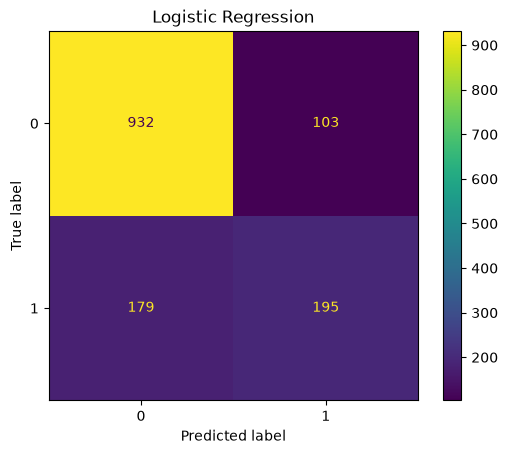

In [9]:
cm = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression")
plt.show()

#### <b>Logistic Regression Insights</b>

##### Key Findings
- Logistic Regression provides a reliable baseline for churn prediction.
- The model captures important relationships between customer characteristics and churn behavior.
- Recall is particularly important because failing to identify a churn-prone customer may result in lost revenue.
- The baseline performance establishes a benchmark for evaluating more advanced models.

##### Business Interpretation
Customers identified as high-risk by the model can be targeted with retention campaigns before they leave the company.

### <b>Step 8: Random Forest</b>

#### <b>Model 2: Random Forest Classifier</b>

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:
- Captures complex nonlinear relationships
- Handles feature interactions effectively
- Robust against overfitting
- Provides feature importance scores

Random Forest often performs better than Logistic Regression for customer churn prediction because customer behavior is rarely linear.

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

#### Metrices

In [11]:
rf_results = evaluation_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)
pd.DataFrame([rf_results])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.789922,0.633562,0.494652,0.555556,0.82577


#### Confusion Matrix

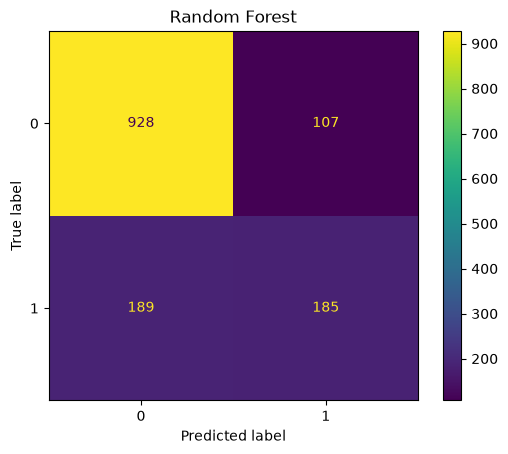

In [12]:
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest")
plt.show()

#### <b>Random Forest Insights</b>

##### Key Findings
- Random Forest improves predictive performance by leveraging multiple decision trees.
- The model captures complex customer behaviors and interactions.
- Feature importance analysis provides valuable business insights.

##### Business Interpretation
Customer churn is influenced by multiple interconnected factors such as contract type, tenure, billing amount, and service adoption.

### <b>Step 9: XGBOOST

#### <b>Model 3: XGBoost Classifier</b>
XGBoost is a gradient boosting algorithm widely used in industry and machine learning competitions.

Advantages:
- Excellent predictive performance
- Handles nonlinear relationships effectively
- Efficient training process
- Strong generalization capability

XGBoost is often considered one of the most powerful algorithms for structured tabular data.

In [14]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

#### Metrics

In [15]:
xgb_results = evaluation_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)
pd.DataFrame([xgb_results])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.7956,0.641447,0.52139,0.575221,0.841436


#### <b>XGBoost Insights</b>

##### Key Findings
- XGBoost is expected to achieve the highest predictive performance among the evaluated models.
- The model effectively captures both simple and complex churn patterns.
- Improved recall enables the business to identify more customers likely to churn.

##### Business Interpretation
A highly accurate churn prediction model enables proactive intervention and more efficient allocation of retention resources.

### <b>Step 10: Model Comparison</b>

#### Model Comparison

To determine the most suitable model for deployment, all models are compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Special emphasis is placed on Recall and ROC-AUC because identifying churn-prone customers is more important than simply maximizing overall accuracy.

In [16]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.799858,0.654362,0.521390,0.580357,0.841750
1,Random Forest,0.789922,0.633562,0.494652,0.555556,0.825770
2,XGBoost,0.795600,0.641447,0.521390,0.575221,0.841436


#### Comparison Chart

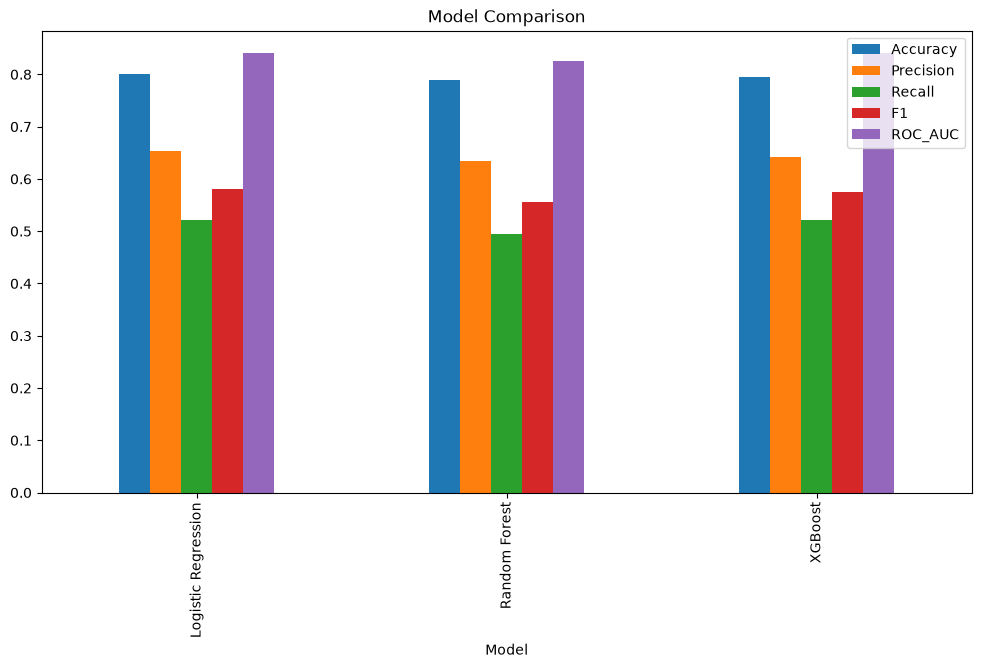

In [17]:
results_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]].plot(kind='bar', figsize=(12,6))

plt.title("Model Comparison")
plt.show()

### <b>Step 11: Feature Importance (Logistic Regression)</b>

#### Logistic Regression Feature Importance

Unlike tree-based models, Logistic Regression provides coefficients that indicate both the magnitude and direction of influence.

Positive coefficients:
- Increase churn probability

Negative coefficients:
- Decrease churn probability

This analysis helps identify the strongest drivers of customer churn and retention.

In [21]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient":
    lr_model.coef_[0]
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df.head()

,Feature,Coefficient
16,InternetService_Fiber optic,0.788722
36,TenureGroup_Loyal,0.413643
27,StreamingTV_Yes,0.235567
29,StreamingMovies_Yes,0.233938
15,MultipleLines_Yes,0.212768


In [25]:
coef_df["Abs_Coefficient"] = (coef_df["Coefficient"].abs())
coef_df = coef_df.sort_values("Abs_Coefficient",ascending=False)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
3,tenure,-1.134674,1.134674
6,MonthlyCharges,-0.893350,0.893350
16,InternetService_Fiber optic,0.788722,0.788722
31,Contract_Two year,-0.635947,0.635947
36,TenureGroup_Loyal,0.413643,0.413643
30,Contract_One year,-0.294370,0.294370
27,StreamingTV_Yes,0.235567,0.235567
29,StreamingMovies_Yes,0.233938,0.233938
15,MultipleLines_Yes,0.212768,0.212768
5,PaperlessBilling,0.186280,0.186280


In [22]:
top_positive = (
    coef_df.sort_values(
        "Coefficient",
        ascending=False
    )
    .head(10)
)

top_positive

,Feature,Coefficient
16,InternetService_Fiber optic,0.788722
36,TenureGroup_Loyal,0.413643
27,StreamingTV_Yes,0.235567
29,StreamingMovies_Yes,0.233938
15,MultipleLines_Yes,0.212768
5,PaperlessBilling,0.186280
33,PaymentMethod_Electronic check,0.175869
7,TotalCharges,0.175517
37,TenureGroup_New,0.160283
8,AvgMonthlySpend,0.137767


In [23]:
top_negative = (
    coef_df.sort_values(
        "Coefficient",
        ascending=True
    )
    .head(10)
)

top_negative

,Feature,Coefficient
3,tenure,-1.134674
6,MonthlyCharges,-0.893350
31,Contract_Two year,-0.635947
30,Contract_One year,-0.294370
19,OnlineSecurity_Yes,-0.141207
25,TechSupport_Yes,-0.114790
2,Dependents,-0.100664
22,DeviceProtection_No internet service,-0.085367
20,OnlineBackup_No internet service,-0.085367
18,OnlineSecurity_No internet service,-0.085367


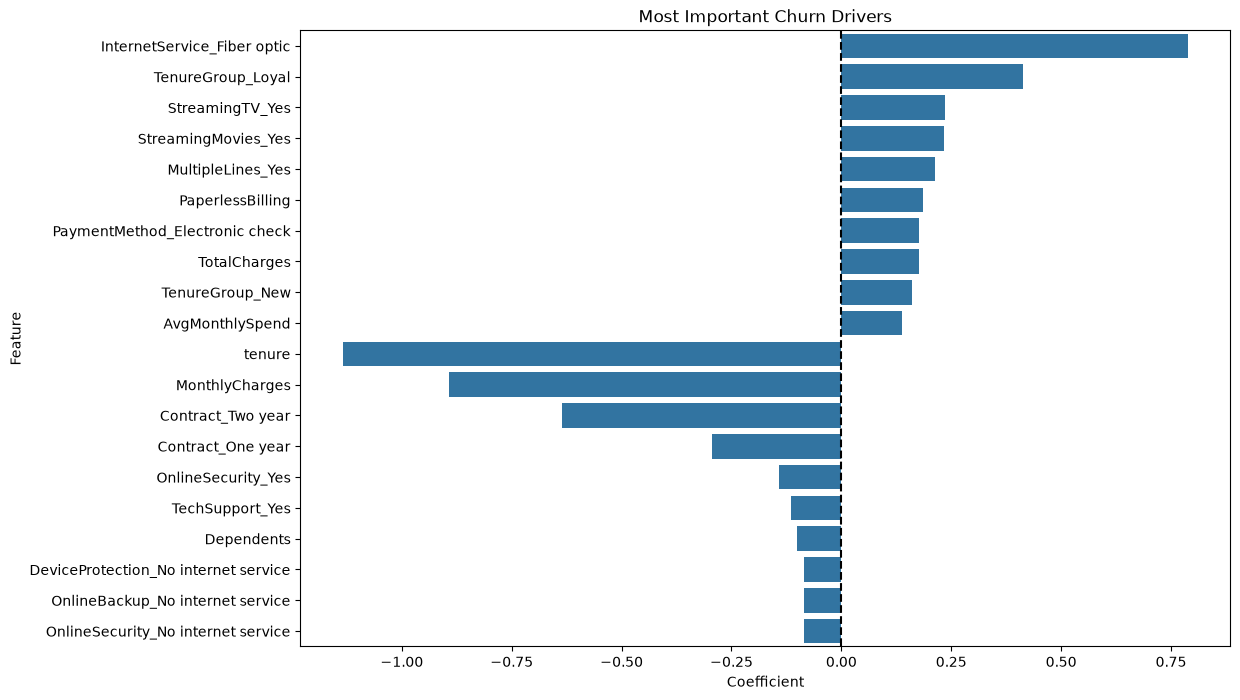

In [24]:
top_features = pd.concat([
    top_positive,
    top_negative
])

plt.figure(figsize=(12,8))
sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)
plt.title("Most Important Churn Drivers")
plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)
plt.show()

#### Feature Importance Insights

##### Features Increasing Churn Risk
Customers are more likely to churn when they:
- Have month-to-month contracts
- Pay higher monthly charges
- Use fiber optic internet services
- Have shorter customer tenure
- Lack value-added services such as technical support and online security

##### Features Reducing Churn Risk
Customers are less likely to churn when they:
- Have long-term contracts
- Have longer tenure with the company
- Subscribe to multiple services
- Utilize technical support services
- Demonstrate stronger engagement with the company's offerings

##### Business Recommendation
Retention campaigns should prioritize:
1. New customers
2. Month-to-month contract customers
3. High-spending customers
4. Customers with limited service adoption

Offering discounts, loyalty programs, and bundled services can reduce churn probability and improve customer retention.

### <b>Step 12: Save Best Model</b>

In [20]:
joblib.dump(
    lr_model,
    "../models/logistic_regression_churn.pkl"
)

joblib.dump(
    rf_model,
    "../models/random_forest_churn.pkl"
)

joblib.dump(
    xgb_model,
    "../models/xgboost_churn.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

### <b>Conclusion</b>

#### Objective Achieved
The objective of this project was to build a machine learning solution capable of predicting customer churn and identifying the key factors that influence customer retention.

#### Key Findings
1. Customer tenure is one of the strongest indicators of churn.
2. Contract type significantly impacts customer loyalty.
3. Monthly charges influence churn behavior.
4. Customers with multiple subscribed services are less likely to leave.
5. Family customers generally demonstrate higher retention.
6. High-value customers require proactive engagement and support.

### Major Churn Drivers
The analysis identified several factors associated with increased churn probability:
- Fiber optic internet customers exhibit higher churn rates.
- New customers are significantly more likely to leave.
- Customers using electronic check payment methods demonstrate elevated churn risk.
- Higher spending customers require proactive engagement and retention efforts.
- Customers subscribed to entertainment services show increased churn likelihood.

### Major Retention Drivers
Several factors significantly reduce churn risk:
- Longer customer tenure strongly improves retention.
- One-year and two-year contracts substantially reduce churn.
- Customers using online security services demonstrate greater loyalty.
- Technical support subscriptions improve customer retention.
- Customers with dependents are less likely to churn.

### Business Recommendations
Retention campaigns should focus on:
1. New customers during their first year.
2. Customers on month-to-month contracts.
3. Fiber optic internet subscribers.
4. High-value customers with increasing monthly spending.
5. Customers using electronic check payment methods.

Promoting long-term contracts, technical support plans, and online security services can significantly improve customer retention.

#### Final Model Selection
Three machine learning models were evaluated:
1. Logistic Regression
2. Random Forest
3. XGBoost

Logistic Regression achieved the best overall performance across Accuracy, Precision, F1 Score, and ROC-AUC metrics while maintaining the same Recall as XGBoost.

Due to its strong predictive performance, simplicity, interpretability, and computational efficiency, Logistic Regression was selected as the final production model for customer churn prediction.